# GOAT-Analyse der PDC Darts World Championship (1994 bis 2026)

**Lehrveranstaltung:** Netzwerkprojekt Wirtschaftsinformatik  
**Dozent:** Prof. Dr. Peter Niemeyer  
**Semester:** SoSe 2026  
**Verfasserin:** Mia Mainka
**Matrikelnummer:** 3047072  
**Abgabedatum:** 29.07.2026

**Hinweis zur Ausführung**

Vor dem ersten Ausführen des Notebooks müssen die folgenden Pakete installiert werden, idealerweise in einer virtuellen Umgebung (venv):

pip install pandas networkx matplotlib scipy

Die Datei darts_matches_world_championship.csv muss im selben Ordner wie das Notebook liegen.

## 1. Pakete und Daten laden

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# csv einlesen, muss im selben ordner liegen
df = pd.read_csv('darts_matches_world_championship.csv')

print('Anzahl Matches:', len(df))
print('Zeitraum:', df['year'].min(), 'bis', df['year'].max())
df.head(3)

Anzahl Matches: 2110
Zeitraum: 1994 bis 2026


,tournament,eid,year,round,player_a,player_a_pid,player_b,player_b_pid,score_a,score_b,winner,winner_pid,loser,loser_pid
0,World Championship,244,1994,Last 24 Group 3rd,Dennis Priestley,8,Graeme Stoddart,1450,3,0,Dennis Priestley,8,Graeme Stoddart,1450
1,World Championship,244,1994,Last 24 Group 3rd,Graeme Stoddart,1450,Jocky Wilson,1794,3,1,Graeme Stoddart,1450,Jocky Wilson,1794
2,World Championship,244,1994,Last 24 Group 3rd,Dennis Priestley,8,Jocky Wilson,1794,3,2,Dennis Priestley,8,Jocky Wilson,1794


## 2. Spieler filtern

Spieler mit weniger als 10 Matches werden nicht berücksichtigt, da ihr Ergebnis statistisch kaum aussagekräftig ist.

In [2]:
# wie oft hat jeder Spieler insgesamt gespielt
alle_spiele = pd.concat([df['winner'], df['loser']]).value_counts()

MIN_MATCHES = 10
top_spieler = alle_spiele[alle_spiele >= MIN_MATCHES].index

# beide Spieler eines Matches müssen das Kriterium erfüllen
df = df[df['winner'].isin(top_spieler) & df['loser'].isin(top_spieler)]

print('Spieler nach Filter:', len(top_spieler))
print('Matches nach Filter:', len(df))

Spieler nach Filter: 125
Matches nach Filter: 1126


## 3. Graph aufbauen

Jeder Spieler ist eine Ecke. Eine gerichtete Kante zeigt vom Verlierer zum Sieger. Das Kantengewicht zählt wie oft der Sieger gegen diesen Verlierer gewonnen hat.

In [3]:
# gerichteter Graph: Richtung der Kante ist wichtig
G = nx.DiGraph()

for _, zeile in df.iterrows():
    sieger    = zeile['winner']
    verlierer = zeile['loser']

    # falls schon gespielt: Gewicht hochzählen, sonst neue Kante anlegen
    if G.has_edge(verlierer, sieger):
        G[verlierer][sieger]['weight'] += 1
    else:
        G.add_edge(verlierer, sieger, weight=1)

print('Ecken (Spieler):', G.number_of_nodes())
print('Kanten (Duelle):', G.number_of_edges())

Ecken (Spieler): 125
Kanten (Duelle): 972


## 4. Netzwerk-Kenngrößen

In [4]:
# weglänge braucht ungerichteten Graphen
U = G.to_undirected()

print('Zusammenhängend:', nx.is_weakly_connected(G))
print('Dichte:           ', round(nx.density(G), 4))
print('Mittlere Weglänge:', round(nx.average_shortest_path_length(U), 4))
print('Durchmesser:       ', nx.diameter(U))

Zusammenhängend: True
Dichte:            0.0627
Mittlere Weglänge: 2.1774
Durchmesser:        4


## 5. Zentralitätsmaße

Die vier Maße aus der Vorlesung. Hauptmaß für das Ranking ist die Eigenvektor-Zentralität: ein Sieg gegen einen starken Spieler zählt mehr.

In [5]:
grad        = nx.degree_centrality(G)
naehe       = nx.closeness_centrality(G)
betweenness  = nx.betweenness_centrality(G, weight='weight')

# max_iter=1000 nötig damit der Algorithmus konvergiert
eigenvektor = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)

print('Nr. 1 Eigenvektor:  ', max(eigenvektor, key=eigenvektor.get))
print('Nr. 1 Grad:         ', max(grad,         key=grad.get))
print('Nr. 1 Nähe:         ', max(naehe,        key=naehe.get))
print('Nr. 1 Betweenness:   ', max(betweenness,   key=betweenness.get))

Nr. 1 Eigenvektor:   Phil Taylor
Nr. 1 Grad:          Phil Taylor
Nr. 1 Nähe:          Phil Taylor
Nr. 1 Betweenness:    Phil Taylor


## 6. GOAT-Ranking

In [6]:
siege         = df.groupby('winner').size()
spieler_liste = list(G.nodes())

ranking = pd.DataFrame()
ranking['Spieler']     = spieler_liste
ranking['Eigenvektor'] = [round(eigenvektor[s], 4) for s in spieler_liste]
ranking['Grad']        = [round(grad[s],        4) for s in spieler_liste]
ranking['Nähe']        = [round(naehe[s],       4) for s in spieler_liste]
ranking['Betweenness']  = [round(betweenness[s],  4) for s in spieler_liste]
ranking['Siege']       = [int(siege.get(s, 0))    for s in spieler_liste]

# größter Wert oben, Rang ab 1
ranking = ranking.sort_values('Eigenvektor', ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1

ranking.head(15)

,Spieler,Eigenvektor,Grad,Nähe,Betweenness,Siege
1,Phil Taylor,0.5256,0.4597,0.5962,0.0786,90
2,Michael van Gerwen,0.4042,0.3871,0.5415,0.0425,49
3,Gary Anderson,0.3648,0.3548,0.5586,0.0570,42
4,Raymond van Barneveld,0.3122,0.2984,0.5277,0.0331,32
5,Peter Wright,0.1877,0.2581,0.4901,0.0352,26
6,Adrian Lewis,0.1851,0.2984,0.5232,0.0488,32
7,Rob Cross,0.1529,0.1774,0.5000,0.0301,15
8,Michael Smith,0.1494,0.2742,0.5254,0.0372,25
9,Simon Whitlock,0.1459,0.2500,0.4960,0.0582,19
10,Dave Chisnall,0.1351,0.2097,0.4960,0.0351,16


## 7. Vergleich: Eigenvektor vs. reine Sieganzahl

Zeigt wo beide Rankings übereinstimmen und wo die Eigenvektor-Methode abweicht, weil sie die Stärke der Gegner berücksichtigt.

In [7]:
# rang nach reiner sieganzahl
siege_rang = ranking[['Spieler', 'Siege']].sort_values('Siege', ascending=False).reset_index(drop=True)
siege_rang.index = siege_rang.index + 1
siege_rang['Rang_Siege'] = siege_rang.index

# eigenvektor-rang aus dem bestehenden ranking
ranking['Rang_Eigenvektor'] = ranking.index

# beide rankings zusammenführen
vergleich = ranking[['Spieler', 'Rang_Eigenvektor']].merge(
    siege_rang[['Spieler', 'Rang_Siege']], on='Spieler'
)
vergleich['Differenz'] = vergleich['Rang_Eigenvektor'] - vergleich['Rang_Siege']

# korrelation der beiden rangfolgen
korr, p = spearmanr(vergleich['Rang_Eigenvektor'], vergleich['Rang_Siege'])
print('Spearman Eigenvektor vs. Siege:', round(korr, 4))
print()
print(vergleich.head(10).to_string(index=False))

Spearman Eigenvektor vs. Siege: 0.8148

              Spieler  Rang_Eigenvektor  Rang_Siege  Differenz
          Phil Taylor                 1           1          0
   Michael van Gerwen                 2           2          0
        Gary Anderson                 3           3          0
Raymond van Barneveld                 4           4          0
         Peter Wright                 5           6         -1
         Adrian Lewis                 6           5          1
            Rob Cross                 7          21        -14
        Michael Smith                 8           7          1
       Simon Whitlock                 9          12         -3
        Dave Chisnall                10          16         -6


## 8. Robustheitscheck

Vergleich mit PageRank: beide Methoden berücksichtigen die Stärke der Gegner, unterscheiden sich aber in der Berechnung. Eine hohe Korrelation zeigt, dass das Ergebnis methodenunabhängig ist.

In [8]:
pagerank  = nx.pagerank(G, weight='weight')

knoten    = list(G.nodes())
eig_werte = [eigenvektor[n] for n in knoten]
pr_werte  = [pagerank[n]    for n in knoten]

korr, p = spearmanr(eig_werte, pr_werte)
print('Spearman-Korrelation:', round(korr, 4))

Spearman-Korrelation: 0.9526


## 9. Visualisierungen

### GOAT-Ranking Top 15

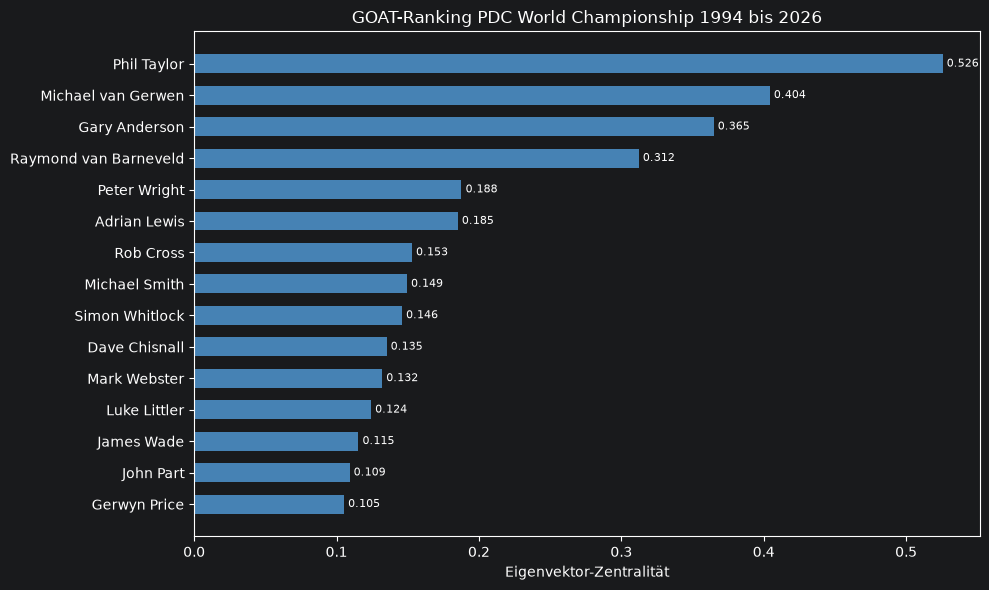

In [9]:
top15 = ranking.head(15)

plt.figure(figsize=(10, 6))
balken = plt.barh(top15['Spieler'], top15['Eigenvektor'], color='steelblue', height=0.6)
plt.xlabel('Eigenvektor-Zentralität')
plt.title('GOAT-Ranking PDC World Championship 1994 bis 2026')
plt.bar_label(balken, fmt='%.3f', padding=3, fontsize=8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('goat_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### Vergleich der vier Zentralitätsmaße

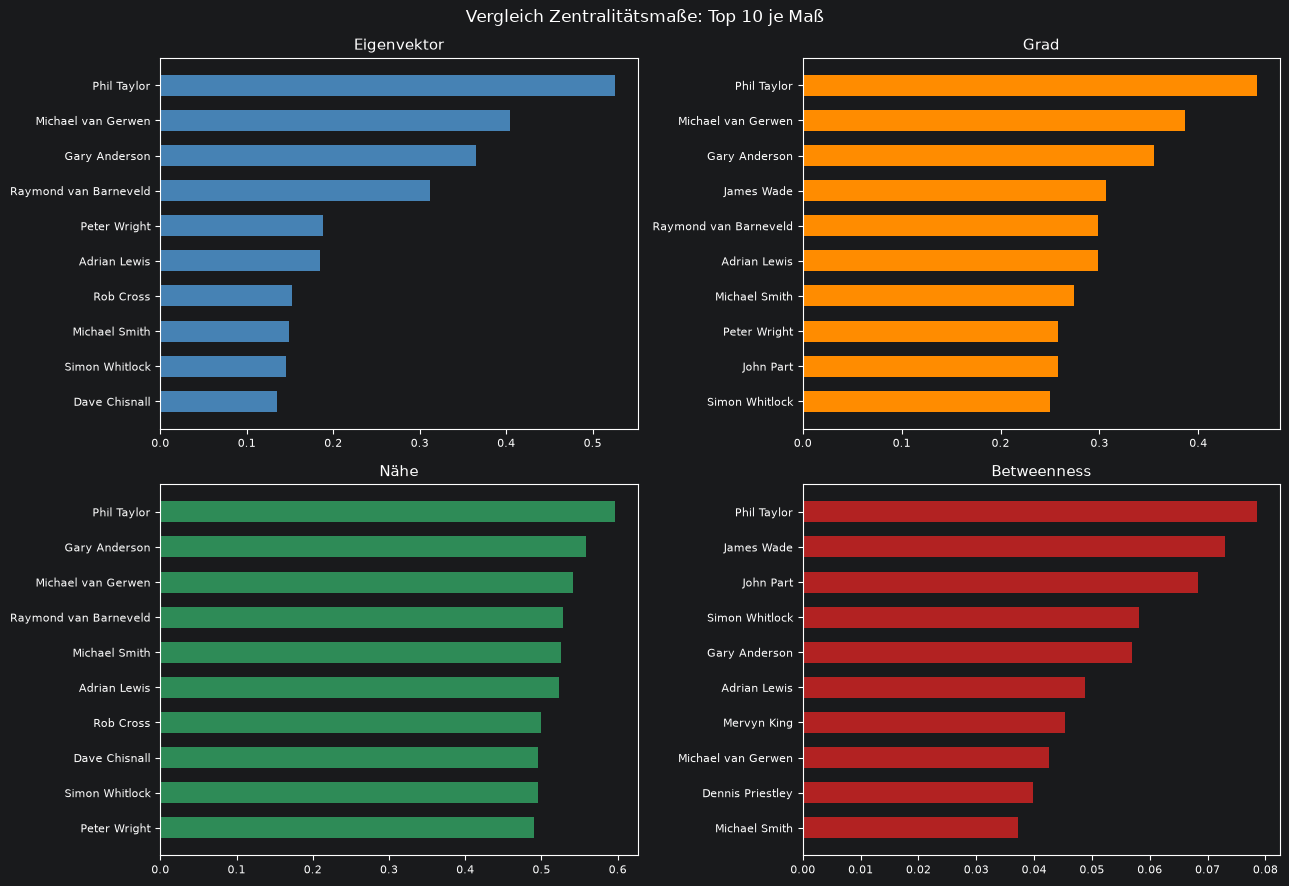

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

masse  = ['Eigenvektor', 'Grad', 'Nähe', 'Betweenness']
farben = ['steelblue', 'darkorange', 'seagreen', 'firebrick']

for ax, mass, farbe in zip(axes.flatten(), masse, farben):
    top = ranking.sort_values(mass, ascending=False).head(10)
    ax.barh(top['Spieler'], top[mass], color=farbe, height=0.6)
    ax.set_title(mass, fontsize=11)
    ax.invert_yaxis()
    ax.tick_params(labelsize=8)

plt.suptitle('Vergleich Zentralitätsmaße: Top 10 je Maß', fontsize=12)
plt.tight_layout()
plt.savefig('zentralitaeten_vergleich.png', dpi=150, bbox_inches='tight')
plt.show()

### Turniernetzwerk 2024 (ab Last 16)

Das Turnier als gerichteter Graph: Ecken sind Spieler, Kanten zeigen vom Verlierer zum Sieger.

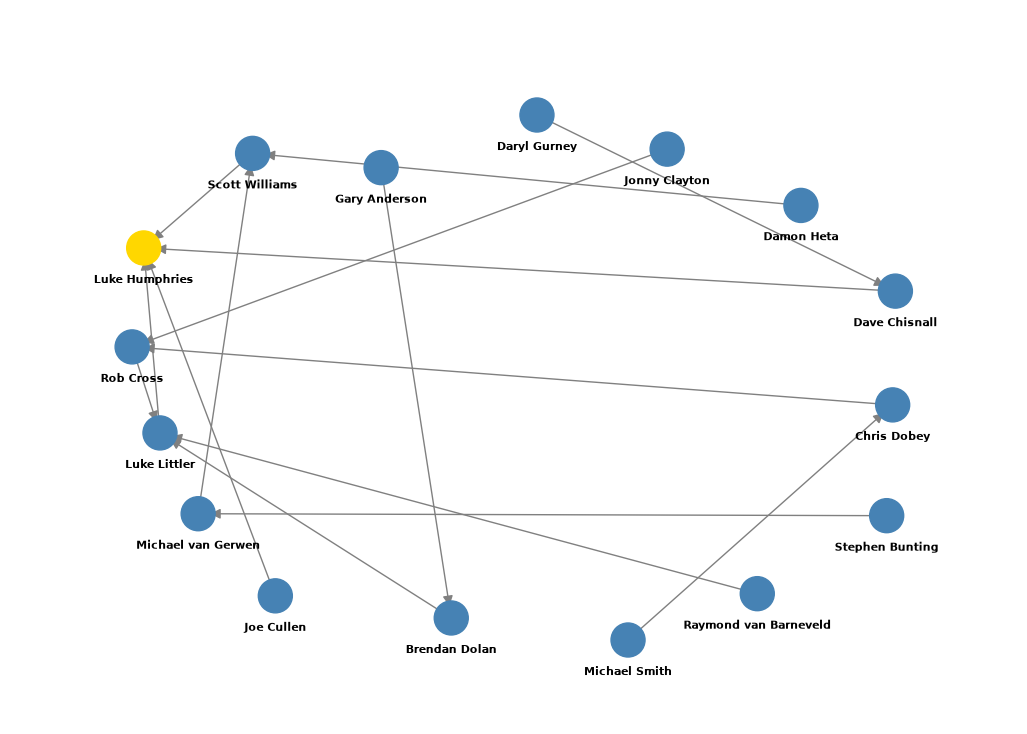

In [14]:
# rohdaten neu laden da wir alle spieler brauchen
df_alle = pd.read_csv('darts_matches_world_championship.csv')

runden  = ['Last 16', 'Quarter Final', 'Semi Final', 'Final']
df_2024 = df_alle[(df_alle['year'] == 2024) & (df_alle['round'].isin(runden))]

# turniergraph aufbauen
G_2024 = nx.DiGraph()
for _, zeile in df_2024.iterrows():
    G_2024.add_edge(zeile['loser'], zeile['winner'])

# sieger gold, alle anderen blau
sieger_2024 = df_2024[df_2024['round'] == 'Final']['winner'].values[0]
farben = ['gold' if n == sieger_2024 else 'steelblue' for n in G_2024.nodes()]

# k sorgt fuer mehr abstand zwischen den ecken
pos = nx.spring_layout(G_2024, seed=42, k=2.5)

# labels etwas unter die punkte setzen
pos_labels = {n: (x, y - 0.12) for n, (x, y) in pos.items()}

plt.figure(figsize=(13, 9), facecolor='white')
nx.draw_networkx_nodes(G_2024, pos, node_color=farben, node_size=600)
nx.draw_networkx_edges(G_2024, pos, edge_color='gray', arrows=True, arrowsize=15)
nx.draw_networkx_labels(G_2024, pos_labels, font_size=8, font_weight='bold')
plt.title('PDC World Championship 2024: Turniernetzwerk ab Last 16 (Gold: Sieger)')
plt.axis('off')
plt.margins(0.1)
plt.savefig('turnier_netzwerk.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()